In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# 1. Load and Prepare Data
df = pd.read_csv('DA task.csv')


In [23]:
df.head(5)

,ORGANIZATION_ID,ACTIVITY_NAME,TIMESTAMP,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000


In [24]:
df.shape

(170526, 7)

In [25]:
df.columns = [col.strip() for col in df.columns] # Clean column names
df.head(10)

,ORGANIZATION_ID,ACTIVITY_NAME,TIMESTAMP,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
5,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.AssignmentChanged,2024-03-27 11:06:20.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
6,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-15 12:14:46.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
7,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-15 12:15:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
8,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-15 12:16:08.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
9,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-15 12:16:59.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000


In [26]:
df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
df['TRIAL_START'] = pd.to_datetime(df['TRIAL_START'])
df['TRIAL_END'] = pd.to_datetime(df['TRIAL_END'])
df['CONVERTED_AT'] = pd.to_datetime(df['CONVERTED_AT'])

In [27]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170526 entries, 0 to 170525
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   ORGANIZATION_ID  170526 non-null  object        
 1   ACTIVITY_NAME    170526 non-null  object        
 2   TIMESTAMP        170526 non-null  datetime64[ns]
 3   CONVERTED        170526 non-null  bool          
 4   CONVERTED_AT     34235 non-null   datetime64[ns]
 5   TRIAL_START      170526 non-null  datetime64[ns]
 6   TRIAL_END        170526 non-null  datetime64[ns]
dtypes: bool(1), datetime64[ns](4), object(2)
memory usage: 8.0+ MB


In [28]:
df.isnull().sum()


ORGANIZATION_ID         0
ACTIVITY_NAME           0
TIMESTAMP               0
CONVERTED               0
CONVERTED_AT       136291
TRIAL_START             0
TRIAL_END               0
dtype: int64

In [29]:
df.duplicated().sum()

np.int64(67631)

In [30]:
df = df.drop_duplicates()

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
#standardize column names
df.columns = df.columns.str.lower()

In [33]:
df = df.copy()
df['days_since_start'] = (df['timestamp'] - df['trial_start']).dt.days

In [34]:
df['time_to_convert'] = (df['converted_at'] - df['trial_start']).dt.days

In [35]:
df.head(5)

,organization_id,activity_name,timestamp,converted,converted_at,trial_start,trial_end,days_since_start,time_to_convert
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,0,NaN
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,0,NaN
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,0,NaN
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,0,NaN
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,0,NaN


In [36]:
org_df = df.groupby('organization_id').agg(
    total_events=('activity_name', 'count'),
    unique_activities=('activity_name', 'nunique'),
    active_days=('timestamp', 'nunique'),
    converted=('converted', 'max')
).reset_index()

In [37]:
org_df.head(5)

,organization_id,total_events,unique_activities,active_days,converted
0,0040dd9ab132b92d5d04bc3acf14d2e2,1004,14,997,False
1,00456fd86311b6095ad05f7e31758f0d,6,4,6,False
2,007d48a2bc006e6eac0348c788d26dfd,5,2,5,False
3,00d6461845d0042b929379c263e9edef,2,2,2,False
4,00d812389a3cffdbf014ba194cbe922e,586,6,586,False


In [38]:
org_df['events_per_day'] = org_df['total_events'] / org_df['active_days']

In [39]:
org_df.head(5)

,organization_id,total_events,unique_activities,active_days,converted,events_per_day
0,0040dd9ab132b92d5d04bc3acf14d2e2,1004,14,997,False,1.007021
1,00456fd86311b6095ad05f7e31758f0d,6,4,6,False,1.000000
2,007d48a2bc006e6eac0348c788d26dfd,5,2,5,False,1.000000
3,00d6461845d0042b929379c263e9edef,2,2,2,False,1.000000
4,00d812389a3cffdbf014ba194cbe922e,586,6,586,False,1.000000


In [40]:
#What % convert?
org_df['converted'].mean()

np.float64(0.21325051759834368)

In [45]:
# What are users doing most in the product?
df['activity_name'].value_counts().head(10)

activity_name
Mobile.Schedule.Loaded                    49540
Scheduling.Shift.Created                  31818
Scheduling.Shift.AssignmentChanged         7608
PunchClock.PunchedIn                       4833
Scheduling.Shift.Approved                  2550
Communication.Message.Created              1576
ShiftDetails.View.Opened                   1433
Scheduling.Availability.Set                1084
Scheduling.Template.ApplyModal.Applied      468
Absence.Request.Created                     388
Name: count, dtype: int64

In [46]:
org_activity = df.groupby(['organization_id', 'activity_name']).size().reset_index(name='count')

org_activity_presence = org_activity.groupby('activity_name')['organization_id'].nunique().sort_values(ascending=False)

org_activity_presence.head(10)

activity_name
Scheduling.Shift.Created                  848
Mobile.Schedule.Loaded                    456
Scheduling.Shift.AssignmentChanged        343
PunchClock.PunchedIn                      211
Scheduling.Shift.Approved                 200
Communication.Message.Created             145
Scheduling.Template.ApplyModal.Applied    108
Scheduling.Availability.Set                59
ShiftDetails.View.Opened                   45
Scheduling.OpenShiftRequest.Created        43
Name: organization_id, dtype: int64

In [47]:
# When this activity occurs, how often does conversion happen?
activity_org = df.groupby(['organization_id', 'activity_name'])['converted'].max().reset_index()

activity_conversion_clean = activity_org.groupby('activity_name')['converted'].mean().sort_values(ascending=False)
activity_conversion_clean.head(10)

activity_name
Scheduling.ShiftHandover.Created          0.363636
Scheduling.ShiftHandover.Accepted         0.333333
Scheduling.OpenShiftRequest.Created       0.302326
Absence.Request.Rejected                  0.285714
Scheduling.Template.ApplyModal.Applied    0.250000
PunchClock.PunchedIn                      0.227488
Scheduling.Availability.Set               0.220339
Scheduling.Shift.Approved                 0.220000
Scheduling.Shift.Created                  0.218160
Scheduling.Shift.AssignmentChanged        0.215743
Name: converted, dtype: float64

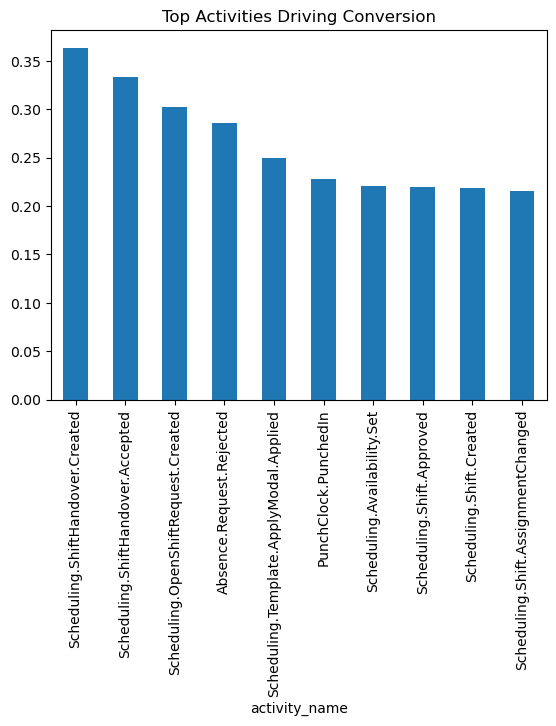

In [48]:
activity_conversion_clean.head(10).plot(kind='bar')
plt.title('Top Activities Driving Conversion')
plt.show()

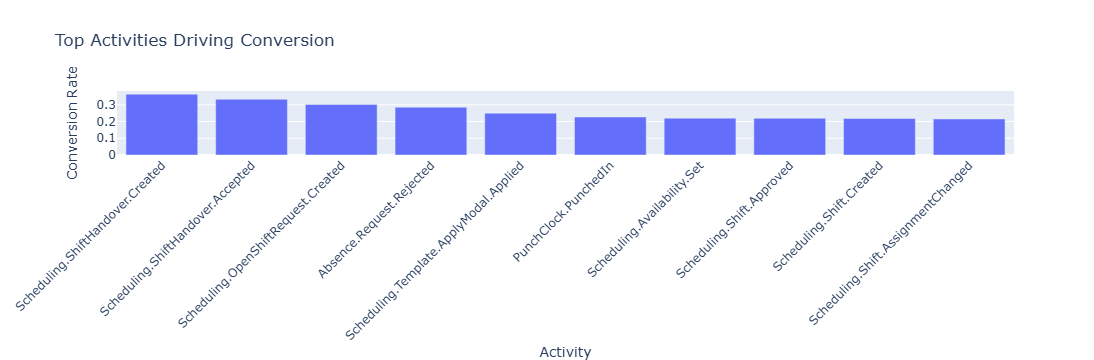

In [49]:
import plotly.express as px

# Get top 10 activities
top_activities = activity_conversion_clean.head(10).reset_index()

# Rename columns for clarity
top_activities.columns = ['activity_name', 'conversion_rate']

# Create interactive bar chart
fig = px.bar(
    top_activities,
    x='activity_name',
    y='conversion_rate',
    title='Top Activities Driving Conversion',
)

# Improve layout
fig.update_layout(
    xaxis_title='Activity',
    yaxis_title='Conversion Rate',
    xaxis_tickangle=-45
)

# Show chart
fig.show()

In [65]:
# Do more active users convert more?
org_df.groupby('converted')['total_events'].mean()

converted
False    106.147368
True     107.878641
Name: total_events, dtype: float64

In [66]:
org_df.groupby('converted')['events_per_day'].mean()

converted
False    1.024264
True     1.023281
Name: events_per_day, dtype: float64

In [67]:
activity_pivot = pd.crosstab(df['organization_id'], df['activity_name'])
activity_pivot = (activity_pivot > 0).astype(int)

org_df = org_df.merge(activity_pivot, on='organization_id')

In [68]:
# First 7 days = decision-making period
# Users who engage early are more likely to convert
early_df = df[df['days_since_start'] <= 7]

early_usage = early_df.groupby('organization_id')['activity_name'].count()

org_df['early_events'] = org_df['organization_id'].map(early_usage).fillna(0)

In [98]:
org_df[['organization_id', 'early_events', 'converted']].head()

,organization_id,early_events,converted
0,0040dd9ab132b92d5d04bc3acf14d2e2,6.0,False
1,00456fd86311b6095ad05f7e31758f0d,6.0,False
2,007d48a2bc006e6eac0348c788d26dfd,5.0,False
3,00d6461845d0042b929379c263e9edef,0.0,False
4,00d812389a3cffdbf014ba194cbe922e,122.0,False


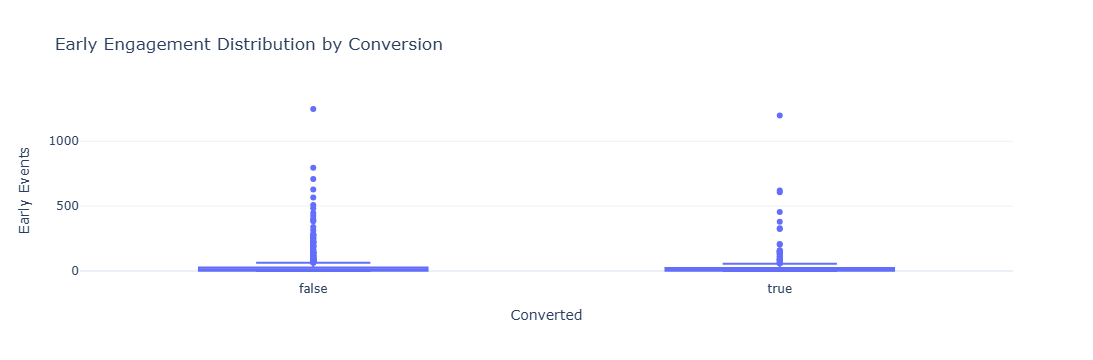

In [97]:
fig = px.box(
    org_df,
    x='converted',
    y='early_events',
    title='Early Engagement Distribution by Conversion',
    labels={
        'converted': 'Converted',
        'early_events': 'Early Events'
    },
    template='plotly_white'
)

fig.show()

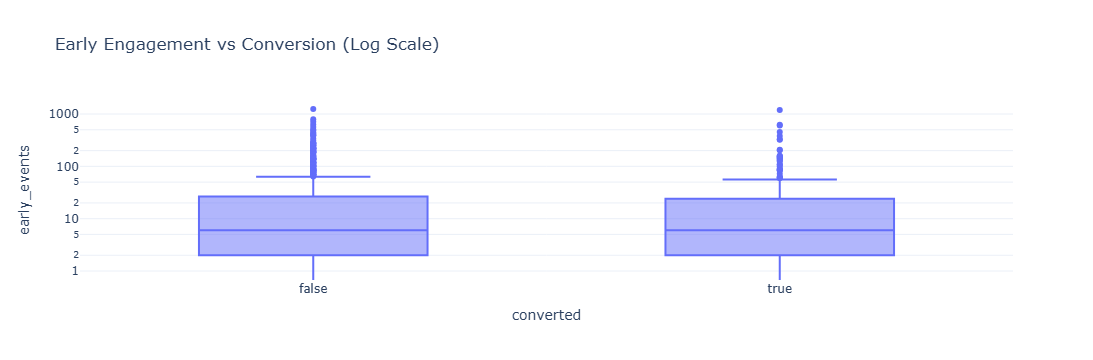

In [102]:
fig = px.box(
    org_df,
    x='converted',
    y='early_events',
    title='Early Engagement vs Conversion (Log Scale)',
    template='plotly_white'
)

fig.update_yaxes(type='log')

fig.show()

In [69]:
org_df.groupby('converted')['early_events'].mean()

converted
False    35.794737
True     40.237864
Name: early_events, dtype: float64

In [70]:
import sqlite3

conn = sqlite3.connect('trial_analysis.db')

In [71]:
df.to_sql('raw_data', conn, if_exists='replace', index=False)

102895

In [90]:
# Did each organization complete each key action?
query = """
SELECT
    organization_id,
    MAX(CASE WHEN activity_name = 'Scheduling.Shift.Created' THEN 1 ELSE 0 END) AS created_shift,
    MAX(CASE WHEN activity_name = 'PunchClock.PunchedIn' THEN 1 ELSE 0 END) AS punch_clock,
    MAX(CASE WHEN activity_name = 'Mobile.Schedule.Loaded' THEN 1 ELSE 0 END) AS viewed_schedule,
    MAX(CASE WHEN activity_name = 'Scheduling.Shift.Approved' THEN 1 ELSE 0 END) AS approved_shift,
    MAX(converted) AS converted
FROM raw_data
GROUP BY organization_id;
"""

conn.execute(query)
conn.commit()
trial_goals.head()

,organization_id,created_shift,punch_clock,viewed_schedule,approved_shift,converted,activated,goals_completed
0,0040dd9ab132b92d5d04bc3acf14d2e2,1,1,1,1,0,1,4
1,00456fd86311b6095ad05f7e31758f0d,1,0,1,0,0,0,2
2,007d48a2bc006e6eac0348c788d26dfd,0,1,1,0,0,0,2
3,00d6461845d0042b929379c263e9edef,1,1,0,0,0,0,2
4,00d812389a3cffdbf014ba194cbe922e,1,1,1,0,0,0,3


In [91]:
# Did the organization complete ALL key actions?
trial_goals['activated'] = (
    (trial_goals['created_shift'] == 1) &
    (trial_goals['punch_clock'] == 1) &
    (trial_goals['viewed_schedule'] == 1) &
    (trial_goals['approved_shift'] == 1)
).astype(int)

In [92]:
trial_goals.groupby('activated')['converted'].mean()

activated
0    0.213038
1    0.214953
Name: converted, dtype: float64

In [93]:
pd.crosstab(trial_goals['activated'], trial_goals['converted'])

converted,0,1
activated,,
0,676,183
1,84,23


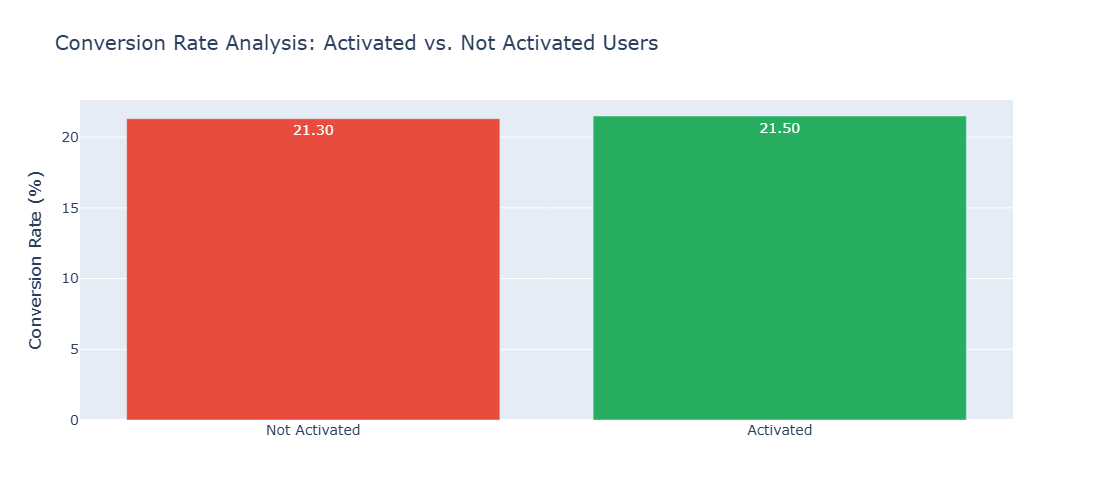

In [94]:
import plotly.express as px

# 1. Prepare your summary data
# This creates a small table with the conversion rate per activation status
plot_data = trial_goals.groupby('activated')['converted'].mean().reset_index()

# 2. Add human-readable labels and percentages
plot_data['status'] = plot_data['activated'].map({1: 'Activated', 0: 'Not Activated'})
plot_data['Conversion Rate (%)'] = plot_data['converted'] * 100

# 3. Create the Interactive Plotly Bar Chart
fig = px.bar(
    plot_data, 
    x='status', 
    y='Conversion Rate (%)',
    color='status', # Differentiate groups by color
    title='Conversion Rate Analysis: Activated vs. Not Activated Users',
    text_auto='.2f', # Show data labels on top of bars
    labels={'status': 'Activation Status', 'Conversion Rate (%)': 'Avg. Conversion Rate (%)'},
    color_discrete_map={'Activated': '#27ae60', 'Not Activated': '#e74c3c'} # Professional Green/Red
)

# 4. Enhance the layout
fig.update_layout(
    showlegend=False,
    xaxis_title=None,
    yaxis_title="Conversion Rate (%)",
    height=500,
    font=dict(size=14)
)

# 5. Display the interactive plot (In a notebook, use fig.show())
fig.show()

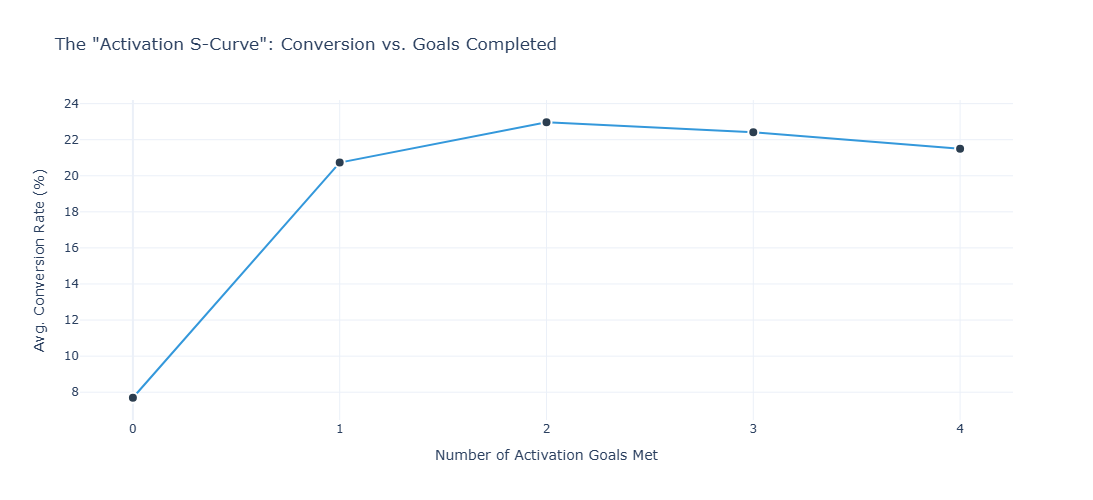

In [95]:
import plotly.express as px

# Step 1: Create goals_completed
trial_goals['goals_completed'] = (
    trial_goals['created_shift'] +
    trial_goals['punch_clock'] +
    trial_goals['viewed_schedule'] +
    trial_goals['approved_shift']
)

# Step 2: Aggregate
line_data = trial_goals.groupby('goals_completed')['converted'].mean().reset_index()

# Step 3: Convert to %
line_data['Conversion Rate (%)'] = line_data['converted'] * 100

# Step 4: Plot
fig = px.line(
    line_data, 
    x='goals_completed', 
    y='Conversion Rate (%)', 
    markers=True,
    title='The "Activation S-Curve": Conversion vs. Goals Completed',
    labels={
        'goals_completed': 'Number of Activation Goals Met', 
        'Conversion Rate (%)': 'Avg. Conversion Rate (%)'
    },
    template='plotly_white'
)

fig.update_traces(
    line_color='#3498db', 
    marker=dict(size=10, color='#2c3e50', line=dict(width=2, color='white'))
)

fig.update_layout(
    hovermode='x unified',
    xaxis=dict(tickmode='linear', dtick=1),
    height=500
)

fig.show()